CASO PRATICO: PREDIZIONE SERIE TEMPORALI CON LSTM

Oggi (2026) le LSTM si usano molto meno rispetto a dieci anni fa. Per molte applicazioni sono state sostituite dai Transformer o da altri modelli di forecasting. Tuttavia, studiarle, è fondamentale perchè insegnano il concetto di memoria temporale.

Cos'è una serie temporale?
Una serie temporale è una sequenza di osservazioni ordinate nel tempo.
Esempio:
la temperatura della settimana da lunedi a domenica.
La domanda è, quale sarà la temperatura di lunedi prossimo, Questa è una previsione di serie temporale.

Una LSTM non guarda solo il valore corrente, guarda anche il passato

Data un serie la rete non riceve tutta la serie, riceve delle finestre
Per esempio
data la serie: 10,12,15,18,21,23,25,27
alla rete viene passata una finestra di 3 valori 10,12,15
produce come output 18
Alla fine otteniamo
10,12,15 output 18
12,15,18 output 21
15,18,21 output 23
18,21,23 output 25
ecc
Questo si chiama sliding windows
La rete cerca di prevedere l'output, all'inizio sbaglia, calcolare l'errore, aggiorna i pesi, ripete migliaia di volte, alla fine impara
In questo modo trasformiamo una serie temporale grezza (un unico flusso continuo di dati) in un insieme di campioni discreti composti da input e output
Questa operazione consiste nel far scorre la finestra di osservazioni di lunghezza fissa lungo la serie per estrarre porzioni di dati che il modello userà per apprendere i pattern ricorsivi.

Importanti sono questi 4 parametri che definiscono il dataset:
1) dimensione della finestra: indica quanti passi temporali passati il modello deve osservare per formulare una previsione
2) Orizzonte di previsione: definisce quanto lontano nel futuro vogliamo spingere la nostra stima del valore
3) Passo o Stride: determina la distanza tra l'inizio di una finestra e la successiva lungo l'asse del tempo
4) Target: rappresenta il valore reale che si verifica immediatamente dopo la fine della finestra di osservazione. E' i nostro obbiettivo finale

Dal flusso al dataset supervisionato.
Mapping Input e Output: ogni finestra di input viene associata a un target specifico creando una coppia fondamentale per l'addestramento supervisionato della rete ricorrente
Efficienza computazionale: la creazione manuale di queste finestre può essere lenta. In TensorFlow utiliziamo strumenti ottimizzati per gestire buffer di memoria efficienti.
Rappresentazione tensoriale: il risultato finale deve essere un tensore tridimensionale dove le dimensioni rappresentano i campioni, i passi temporali, e le feature.

Dobbiamo bilanciare la dimensione della finestra per evitare che sia troppo corta per catturare la stagionalità o troppo lunga per i limiti di memoria della rete.
Con i dati pronti passiamo alla fase più interessante: la predizione

Predizione del valore successivo.
L'obbiettivo Many-to-One
Una volta strutturati i dati, il compito del modello è mappare la sequenza temporale di input in un singolo valore numerico che rappresenta l'istante temporale immediatamente successivo.
Questo approccio è fondamentale per applicazioni come la previsione del meteo, l'analisi dei mercati finanziari o il monitoraggio dei segnali industriali.

Ma quele architettura è piu' adatta per la regressione temporale?
Dalle ricorrenze al valore puntuale.
- Layer Ricorrente: un modulo LSTM o GRU (per la versione più leggera) elabora la sequenza mantenendo uno stato interno che riassume l'intera finestra. Tuttavia LSTM da sola non basta, alla fine abbiamo bisogno di un layer denso con un unico neurone
- Vettore di stati finale: solo l'output dell'ultimo istante temporale della sequenza viene solitamente passato ai layer successivi
- Layer Denso: uno o più layer completamente connessi trasformano le feature astratte della sequenza in una scala numerica
- Funzione Loss: per la predizione di valori continui si utilizza tipicamente l'errore quadratico medio per penalizzare le deviazioni

Normalizzazione dei dati: Le LSTM odiano in numeri troppo grandi o troppo diversi tra di loro. Scalare i dati prima della finestratura per aiutare la convergenza del gradiente.
Stabilità della predizione: il modello deve imparare a ignorare il rumore ad alta frequenza per concentrarsi sul trend sottostante della serie storica
Output scalare: l'ultimo layer avrà  un solo neurone con attivazione lineare per restituire il valore predetto senza vincoli di intervallo.

Il modello potrebbe cadere nella trappola della predizione naive, ovvero limitarsi a restituire il valore dell'istasnte precedente come previsione per il futuro.
Per evitare questo, è necessario valutare se il modello sta davvero imparando la dinamica del sistema o se sta solo copiando l'ultimo input ricevuto.
Se vidamo una loss molto bassa ed un grafico che sembra solo traslato di un passo, siamo caduti in questa situazione.
Dobbiamo assicurarci che il modello stia capendo la dinamica, non copiando l'ultimo dato.
Per capire se un modello sta imparando, dobbiamo vedere le sue predizioni sovrapposte alla realtà, la grafica diventa quindi importante

Struenti di valutazione visuale
Interpretare il comportamento del modello
- Plotting comparativo: disegnare sulla stessa scala temporale i dati reali del set di test e le corrispondenti predizioni
- Analisi del residuo: osservare la differenza punto a punto tra realtà e modello per identificare errori sistemici. Se la differenza è sempre positiva d'estate e negativa d'inverno il nostro modello ha un bias
- Denormalizzazione: riportare i valori predetti sulla scala originale per dare un senso fisico ai risultati ottenuti
- Lag temporale: verificare se la curva predetta risulta traslata rispetto a quella reale, segno di modello poco reattivo.

Ma oltre ai grafici, quale metriche ci possono aiutare?
- Errore assoluto medio (MAE): fornisce una misura diretta della distanza media tra la realtà e la previsione, espressa nelle unità di misura originali del dato
- Visualizzazione dello Zoom: è utile analizzare finestre temporali ristrette per osservare come la rete reagisce ai cambiamenti improvvisi di direzione della serie
- Ripartizione dell'errore: calcolare l'errore separatamente per le zone di alta e bassa volatiltà aiuta a capire i limiti del modello addestrato.

Ma attenzione a come si costruiscono i dati di test, per le serie temporali il data lake è come il peccato originale. Non posso prevedere i dati del 2024 guardando i dati del 2025. 


La LSTM vede davvero il calendario
No, la LSTM vede solo nmeri, non sa cos'è lunedi


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 429ms/step - loss: 0.1630 - mae: 0.3666
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 423ms/step - loss: 0.0267 - mae: 0.1293
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 408ms/step - loss: 0.0277 - mae: 0.1385
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 425ms/step - loss: 0.0141 - mae: 0.0925
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - loss: 0.0180 - mae: 0.1058
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 414ms/step - loss: 0.0142 - mae: 0.0930
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - loss: 0.0131 - mae: 0.0898
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - loss: 0.0137 - mae: 0.0922
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - loss: 0.0126 - mae: 0.0876
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - loss: 0.0128 - mae: 0.0880
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - loss: 0.0125 - mae: 0.0870
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 473ms/step - loss: 0.0124 - mae: 0.0872
Epoch 13/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 527ms/ste

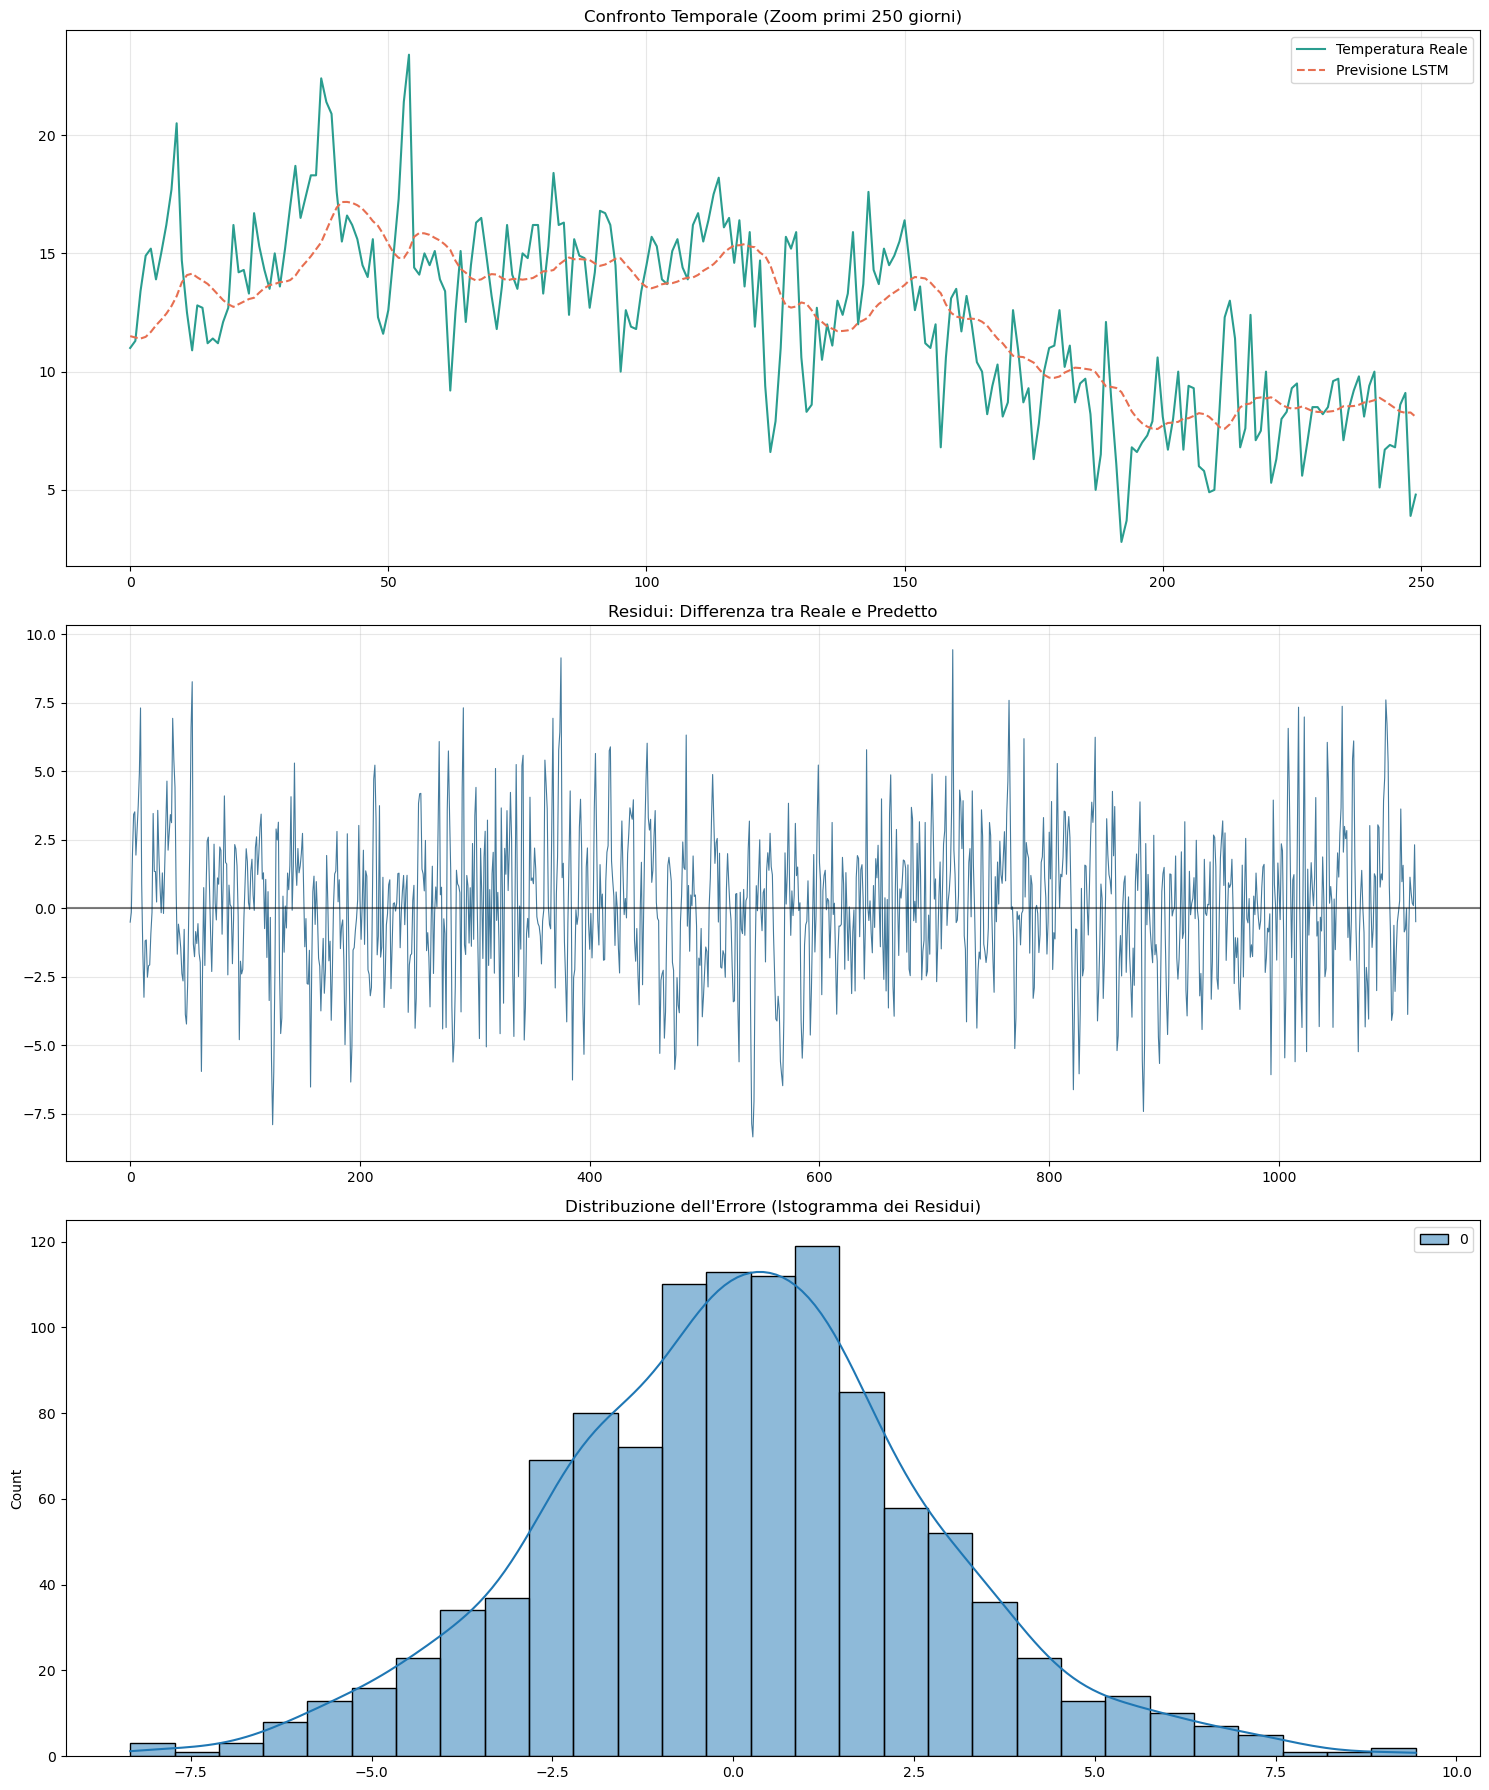

In [1]:
import os

# ---------------------------------------------------------
# 1. SETUP DELL'AMBIENTE E SELEZIONE DEL MOTORE (BACKEND)
# ---------------------------------------------------------

# Disattiva le ottimizzazioni oneDNN di TensorFlow per evitare discrepanze numeriche 
# minori dovute agli arrotondamenti in virgola mobile, pulendo l'output della console.
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# Keras 3 è "multi-backend". Qui istruiamo Keras a usare PyTorch per i calcoli dei gradienti 
# e la gestione dei tensori, pur mantenendo la sintassi Keras semplice e leggibile.
os.environ["KERAS_BACKEND"] = "torch"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import tensorflow as tf
import keras
from keras import layers, utils
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------------------------------------------------
# 2. DATA INGESTION E NORMALIZZAZIONE
# ---------------------------------------------------------

# Carichiamo il dataset "Daily Minimum Temperatures". 
# parse_dates e index_col sono fondamentali per trattare i dati come una vera Serie Temporale.
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

# Le reti neurali, specialmente le LSTM, faticano con range di dati ampi (es. da -5 a 30).
# Usiamo MinMaxScaler per comprimere i dati nel range [0, 1]. 
# Questo accelera la convergenza dell'ottimizzatore e previene l'esplosione dei gradienti.
values = df.values.astype('float32')
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# Definiamo l'iperparametro WINDOW_SIZE: quanti giorni "passati" guardiamo per prevedere il "domani".
# SPLIT_TIME: dividiamo i dati cronologicamente (il passato istruisce il futuro).
WINDOW_SIZE = 30  
BATCH_SIZE = 512  # Sfruttiamo il parallelismo della GPU
SPLIT_TIME = 2500 #divido tra traing e test

train_series = scaled_values[:SPLIT_TIME]
test_series = scaled_values[SPLIT_TIME:]

# ---------------------------------------------------------
# 3. PIPELINE DATI ASINCRONA (OTTIMIZZAZIONE HARDWARE)
# ---------------------------------------------------------

def create_dataset(series, window_size, batch_size, is_train=True):
    # Trasforma l'array piatto in finestre scorrevoli. 
    # Esempio: [1,2,3,4,5] con finestra 3 diventa: Input [1,2,3] -> Target [4]
    dataset = utils.timeseries_dataset_from_array(
        data=series[:-1],          # I dati di input
        targets=series[window_size:], # Cosa vogliamo predire (valore al tempo t + window_size)
        sequence_length=window_size,
        batch_size=batch_size,
        shuffle=is_train           # Shuffliamo solo nel training per rompere le correlazioni temporali locali
    )
    
    # .cache(): Carica i dati in RAM dopo la prima epoca. Elimina i colli di bottiglia del disco.
    # .prefetch(): Permette alla CPU di preparare il prossimo batch mentre la GPU calcola quello attuale.
    dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_set = create_dataset(train_series, WINDOW_SIZE, BATCH_SIZE)
test_set = create_dataset(test_series, WINDOW_SIZE, BATCH_SIZE, is_train=False)

# ---------------------------------------------------------
# 4. ARCHITETTURA DELLA RETE (FUNCTIONAL API)
# ---------------------------------------------------------

# Definiamo l'input: una sequenza di 30 giorni con 1 singola caratteristica (temperatura).
inputs = keras.Input(shape=(WINDOW_SIZE, 1))

# La LSTM è ideale per catturare dipendenze a lungo termine.
# return_sequences=True: Necessario perché il secondo layer LSTM ha bisogno di una sequenza in input, non di un singolo vettore.
x = layers.LSTM(64, return_sequences=True)(inputs)

# Dropout: Spegne casualmente il 10% dei neuroni. Impedisce alla rete di "imparare a memoria" 
# il rumore dei dati (overfitting), costringendola a imparare pattern robusti.
x = layers.Dropout(0.1)(x)

# Secondo layer LSTM: riassume la sequenza in un singolo vettore di caratteristiche da 32 elementi.
x = layers.LSTM(32)(x)

# Output finale: un singolo valore lineare che rappresenta la temperatura predetta.
outputs = layers.Dense(1)(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# AdamW: Evoluzione di Adam con una gestione del decadimento dei pesi (weight decay) 
# separata dal gradiente, migliorando la capacità di generalizzazione del modello.
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3),
    loss="mse",   # Mean Squared Error: penalizza pesantemente gli errori grandi.
    metrics=["mae"] # Mean Absolute Error: errore medio in gradi centigradi.
)

# ---------------------------------------------------------
# 5. TRAINING E CALLBACKS
# ---------------------------------------------------------

# EarlyStopping: Monitora la perdita. Se smette di scendere per 5 epoche (patience), 
# ferma l'addestramento e ripristina i pesi migliori. Risparmia tempo ed energia.
callbacks = [
    keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
]

history = model.fit(train_set, epochs=50, callbacks=callbacks, verbose=1)

# ---------------------------------------------------------
# 6. INFERENZA E "DISACCOPPIAMENTO" DATI
# ---------------------------------------------------------

# Il modello genera predizioni scalate (tra 0 e 1).
forecast_scaled = model.predict(test_set)

# scaler.inverse_transform: Operazione fondamentale per riportare i numeri ai gradi Celsius (°C).
predicted = scaler.inverse_transform(forecast_scaled)

# Allineamento: Poiché usiamo una finestra di 30 giorni, il modello non può predire 
# i primi 30 giorni del set di test. Dobbiamo tagliare 'actual' di conseguenza per il confronto.
actual = values[SPLIT_TIME + WINDOW_SIZE:]

# ---------------------------------------------------------
# 7. ANALISI DEI RESIDUI (VALIDAZIONE STATISTICA)
# ---------------------------------------------------------

# Il residuo è l'errore puro: Valore Reale - Valore Predetto.
residuals = actual - predicted

# Calcolo metriche standard di errore
mse_val = mean_squared_error(actual, predicted)
mae_val = mean_absolute_error(actual, predicted)

print(f"\n--- PERFORMANCE METRICS ---")
print(f"MSE (Errore Quadratico Medio): {mse_val:.4f}")
print(f"MAE (Errore Assoluto Medio): {mae_val:.4f} °C")

# ---------------------------------------------------------
# 8. VISUALIZZAZIONE E DIAGNOSTICA
# ---------------------------------------------------------

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 18))

# GRAFICO 1: PERFORMANCE TEMPORALE
# Visualizziamo come la previsione segue la realtà. Un buon modello segue i picchi e le valli.
ax1.plot(actual[:250], label="Temperatura Reale", color='#2A9D8F', linewidth=1.5)
ax1.plot(predicted[:250], label="Previsione LSTM", color='#E76F51', linestyle='--')
ax1.set_title("Confronto Temporale (Zoom primi 250 giorni)")
ax1.legend()
ax1.grid(alpha=0.3)

# GRAFICO 2: ANALISI DEI RESIDUI (ERRORE NEL TEMPO)
# Se i residui mostrano un pattern (es. onde), la rete sta perdendo informazioni stagionali.
# Se sono casuali (rumore bianco), la rete ha estratto tutto il segnale possibile.
ax2.plot(residuals, color='#457B9D', linewidth=0.8)
ax2.axhline(0, color='black', linestyle='-', alpha=0.5)
ax2.set_title("Residui: Differenza tra Reale e Predetto")
ax2.grid(alpha=0.3)

# GRAFICO 3: DISTRIBUZIONE DELL'ERRORE
# Idealmente, deve essere una campana di Gauss (Normalità) centrata sullo zero.
# Un istogramma "spostato" indica un Bias (il modello sovrastima o sottostima sistematicamente).
sns.histplot(residuals, kde=True, ax=ax3, color='#1D3557')
ax3.set_title("Distribuzione dell'Errore (Istogramma dei Residui)")



plt.tight_layout()
plt.show()